In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.integrate import solve_ivp

import pysindy as ps
from pysindy.feature_library import WeakPDELibrary, WeightedWeakPDELibrary

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
})


In [2]:
def compressible(t, U, dx, N, mu, RT):
    """
    U is flattened (3 * N * N,),
    we reshape to (N, N, 3) with components (u, v, rho).
    """
    uvr = U.reshape(N, N, 3)
    u = uvr[:, :, 0]
    v = uvr[:, :, 1]
    rho = uvr[:, :, 2]

    FD1x = ps.differentiation.FiniteDifference(d=1, axis=0, periodic=True)
    FD1y = ps.differentiation.FiniteDifference(d=1, axis=1, periodic=True)
    FD2x = ps.differentiation.FiniteDifference(d=2, axis=0, periodic=True)
    FD2y = ps.differentiation.FiniteDifference(d=2, axis=1, periodic=True)

    ux  = FD1x._differentiate(u, dx)
    uy  = FD1y._differentiate(u, dx)
    uxx = FD2x._differentiate(u, dx)
    uyy = FD2y._differentiate(u, dx)

    vx  = FD1x._differentiate(v, dx)
    vy  = FD1y._differentiate(v, dx)
    vxx = FD2x._differentiate(v, dx)
    vyy = FD2y._differentiate(v, dx)

    p   = rho * RT
    px  = FD1x._differentiate(p, dx)
    py  = FD1y._differentiate(p, dx)

    ret = np.zeros_like(uvr)
    # u_t
    ret[:, :, 0] = -(u * ux + v * uy) - (px - mu * (uxx + uyy)) / rho
    # v_t
    ret[:, :, 1] = -(u * vx + v * vy) - (py - mu * (vxx + vyy)) / rho
    # rho_t
    ret[:, :, 2] = -(u * px / RT + v * py / RT + rho * ux + rho * vy)

    return ret.reshape(-1)



In [3]:
def make_initial_condition(X, Y, L, ic_type="taylor-green", perturb_scale=1.0, rng=None):
    """
    Return (U0, V0, RHO0) for a chosen flow configuration.

    X, Y : meshgrid on [0,L]x[0,L]
    """
    if rng is None:
        rng = np.random.default_rng()

    if ic_type == "taylor-green":
        U0 = (-np.sin(2 * np.pi / L * X) + 0.5 * np.cos(2 * 2 * np.pi / L * Y))
        V0 = (0.5 * np.cos(2 * np.pi / L * X) - np.sin(2 * 2 * np.pi / L * Y))
        RHO0 = 1.0 + 0.5 * np.cos(2 * np.pi / L * X) * np.cos(2 * 2 * np.pi / L * Y)

        perturb = perturb_scale * np.exp(
            -((X - L / 2) ** 2 + (Y - L / 2) ** 2) / (0.1 * L) ** 2
        ) * (0.5 * rng.standard_normal(U0.shape))

        U0 += perturb
        V0 -= perturb

    elif ic_type == "shear-layer":
        U0 = np.tanh((Y - L / 2) / 0.1)
        V0 = 0.05 * np.sin(2 * np.pi * X / L)
        RHO0 = 1.0 + 0.1 * np.exp(-((Y - L / 2) ** 2) / (0.1**2))

    else:
        raise ValueError(f"Unknown initial condition: {ic_type}")

    return U0, V0, RHO0


In [4]:
def generate_compressible_flow(
    n_traj=1,
    N=64,
    Nt=101,
    L=5.0,
    T=2.0,
    mu=1.0,
    RT=1.0,
    noise_level=0.0,
    seed=42,
    noise_ic=0.1,
):
    """
    Generate one or more trajectories for isothermal 2D compressible flow.

    Returns
    -------
    trajectories : list of ndarray
        Each element has shape (N, N, Nt, 3) with components (u, v, rho).
    grid : ndarray of shape (N, N, Nt, 3)
        Spatiotemporal grid with entries (x, y, t).
    ts : list of ndarray
        Time arrays, each of length Nt.
    """
    rng = np.random.default_rng(seed)
    t = np.linspace(0.0, T, Nt)
    x = np.linspace(0.0, L, N, endpoint=False)
    y = np.linspace(0.0, L, N, endpoint=False)
    dx = x[1] - x[0]
    X, Y = np.meshgrid(x, y, indexing="ij")

    trajectories = []
    ts = []

    for _ in range(n_traj):
        y0 = np.zeros((N, N, 3))
        y0[:, :, 0] = (
            -np.sin(2 * np.pi / L * x)[:, np.newaxis]
            + 0.5 * np.cos(2 * 2 * np.pi / L * y)[np.newaxis, :]
        )
        y0[:, :, 1] = (
            0.5 * np.cos(2 * np.pi / L * x)[:, np.newaxis]
            - np.sin(2 * 2 * np.pi / L * y)[np.newaxis, :]
        )
        y0[:, :, 2] = (
            1
            + 0.5
            * np.cos(2 * np.pi / L * x)[:, np.newaxis]
            * np.cos(2 * 2 * np.pi / L * y)[np.newaxis, :]
            )


        sol = solve_ivp(
            compressible,
            (t[0], t[-1]),
            y0=y0.reshape(-1),
            t_eval=t,
            args=(dx, N, mu, RT),
            method="RK45",
            rtol=1e-8,
            atol=1e-8,
        )

        u_field = sol.y.reshape(N, N, 3, -1).transpose(0, 1, 3, 2)  # (N, N, Nt, 3)

        if noise_level > 0.0:
            u_field += noise_level * rng.standard_normal(size=u_field.shape)

        trajectories.append(u_field)
        ts.append(t)

    # Spatiotemporal grid (same for all trajectories)
    grid = np.zeros((N, N, Nt, 3))
    grid[:, :, :, 0] = X[:, :, None]
    grid[:, :, :, 1] = Y[:, :, None]
    grid[:, :, :, 2] = t[None, None, :]

    return trajectories, grid, ts


In [5]:
L = 5.0
N = 64          # spatial resolution
Nt = 500        # number of time snapshots
T = 2.5
mu = 1.0
RT = 1.0

trajectories, grid, ts = generate_compressible_flow(
    n_traj=1,
    N=N,
    Nt=Nt,
    L=L,
    T=T,
    mu=mu,
    RT=RT,
    noise_level=0.0,     # clean reference
    seed=1,
    noise_ic=0.0,
)

u_field = trajectories[0]  # (N, N, Nt, 3)
t = ts[0]                  # (Nt,)

print("u_field shape (N, N, Nt, 3):", u_field.shape)
print("t shape:", t.shape)
print("grid shape:", grid.shape)

# Keep layout as (Nx, Ny, Nt, n_states)
U_clean = u_field

# --- Heteroscedastic noise field based on temporal derivatives --------
# Extract components: (N, N, Nt)
u   = U_clean[..., 0]
v   = U_clean[..., 1]
rho = U_clean[..., 2]

dt = t[1] - t[0]

def ddt(f, dt):
    """Centered finite difference in time with periodic wrap (time axis = 2)."""
    return (np.roll(f, -1, axis=2) - np.roll(f, 1, axis=2)) / (2.0 * dt)

u_t   = ddt(u, dt)
v_t   = ddt(v, dt)
rho_t = ddt(rho, dt)

# Magnitude of temporal derivative (N, N, Nt)
time_deriv_mag = np.sqrt(u_t**2 + v_t**2)

sigma0 = 1e-3
alpha  = 0.025   # controls noise level

variance = (sigma0 + alpha * time_deriv_mag)**2    # (N, N, Nt)
variance = np.maximum(variance, 1e-16)
std = np.sqrt(variance)

rng = np.random.default_rng(123)
noise = std[..., None] * rng.standard_normal(size=U_clean.shape)
U_noisy = U_clean + noise

print("variance shape:", variance.shape)
print("std range:", std.min(), "to", std.max())
print("U_noisy shape:", U_noisy.shape)


u_field shape (N, N, Nt, 3): (64, 64, 500, 3)
t shape: (500,)
grid shape: (64, 64, 500, 3)
variance shape: (64, 64, 500)
std range: 0.0010076892105670503 to 4.274245333214015
U_noisy shape: (64, 64, 500, 3)


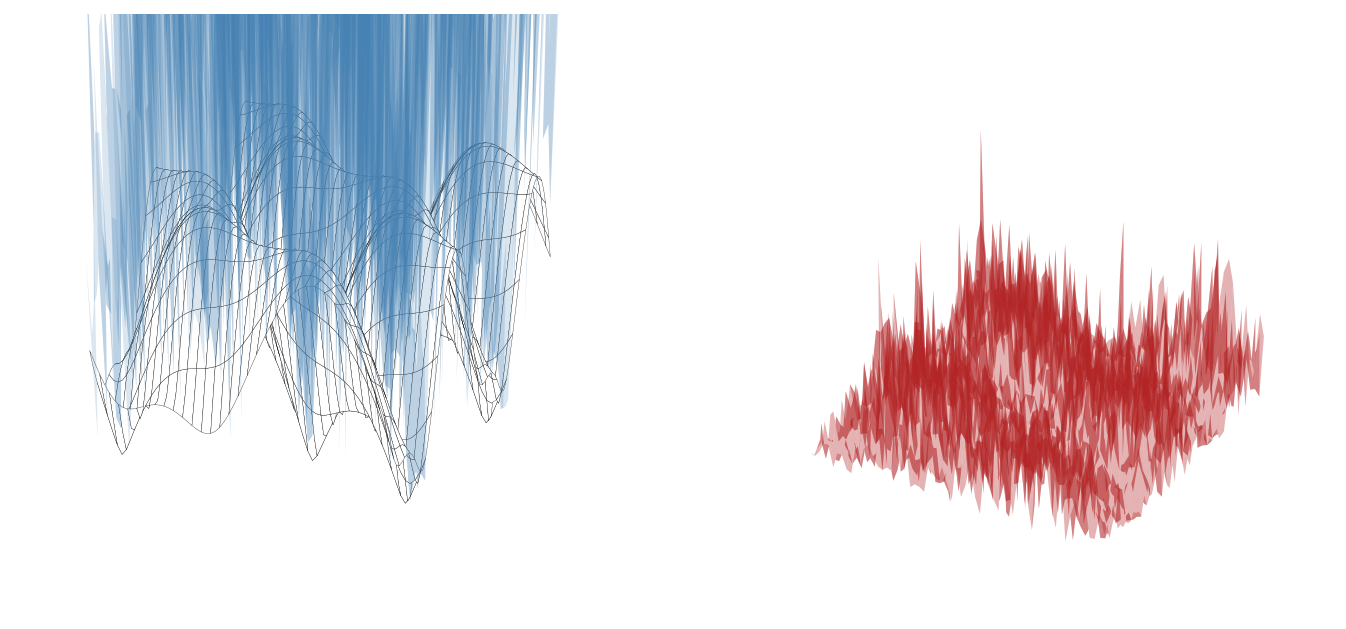

MovieWriter imagemagick unavailable; using Pillow instead.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

# --- spatial grid (same as your static code) ---
x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)
Xg, Yg = np.meshgrid(x, y, indexing="ij")

# --- helper to compute |u| from U[..., 0:2] ---
def velocity_magnitude(U):
    return np.sqrt(U[..., 0]**2 + U[..., 1]**2)

# Precompute velocity magnitudes over time: (N, N, Nt)
vel_clean_all = velocity_magnitude(U_clean)        # (N, N, Nt)
vel_noisy_all = velocity_magnitude(U_noisy)        # (N, N, Nt)
err_all       = np.abs(vel_noisy_all - vel_clean_all)

# Global z-scales (fixed for all frames)
zmin_vel = 0.0
zmax_vel = np.max(vel_clean_all)
zmin_err = 0.0
zmax_err = np.max(err_all)

# --- figure and axes -------------------------------------------------
fig = plt.figure(figsize=(10, 4), dpi=150)

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

for ax in (ax1, ax2):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_axis_off()

# fix z-scale so you see shape changes, not rescaling
ax1.set_zlim(zmin_vel, zmax_vel)
ax2.set_zlim(zmin_err, zmax_err)

# Initial frame (frame 0)
k0 = 0
vel_mag0       = vel_clean_all[:, :, k0]
vel_mag_noisy0 = vel_noisy_all[:, :, k0]
err0           = err_all[:, :, k0]

white_surface0 = np.ones_like(vel_mag0)

# Left: clean (gray) + noisy (steelblue)
ax1.plot_surface(
    Xg, Yg, vel_mag_noisy0,
    color="steelblue",
    edgecolor=None,
    linewidth=0,
    antialiased=True,
    shade=False,
    alpha=0.2,
)
ax1.plot_surface(
    Xg, Yg, vel_mag0,
    facecolors=plt.cm.gray(white_surface0),
    edgecolor="black",
    linewidth=0.15,
    antialiased=True,
    shade=False,
    alpha=1.0,
)

# Right: error surface (red)
ax2.plot_surface(
    Xg, Yg, err0,
    color="#b32425",
    linewidth=0,
    antialiased=True,
    shade=False,
    alpha=0.35,
)

plt.tight_layout(pad=0)

# --- update function for animation -----------------------------------
def update(frame):
    # Remove old surfaces cleanly
    for coll in list(ax1.collections):
        coll.remove()
    for coll in list(ax2.collections):
        coll.remove()

    vel_mag       = vel_clean_all[:, :, frame]
    vel_mag_noisy = vel_noisy_all[:, :, frame]
    err           = err_all[:, :, frame]

    white_surface = np.ones_like(vel_mag)

    # Left panel: clean + noisy
    ax1.plot_surface(
        Xg, Yg, vel_mag_noisy,
        color="steelblue",
        edgecolor=None,
        linewidth=0,
        antialiased=True,
        shade=False,
        alpha=0.2,
    )
    ax1.plot_surface(
        Xg, Yg, vel_mag,
        facecolors=plt.cm.gray(white_surface),
        edgecolor="black",
        linewidth=0.15,
        antialiased=True,
        shade=False,
        alpha=1.0,
    )

    # Right panel: error
    ax2.plot_surface(
        Xg, Yg, err,
        color="#b32425",
        linewidth=0,
        antialiased=True,
        shade=False,
        alpha=0.35,
    )

    return []

# --- create animation -------------------------------------------------
# e.g. use every 10th frame so it runs faster and frame index is explicit
frame_indices = list(range(0, Nt, 10))

anim = animation.FuncAnimation(
    fig,
    update,
    frames=frame_indices,
    interval=50,   # ms between frames
    blit=False
)

plt.show()

# Save to file (pick one)
anim.save("velocities_3d.mp4", writer="ffmpeg", fps=20, dpi=150)
anim.save("velocities_3d.gif", writer="imagemagick", fps=15)


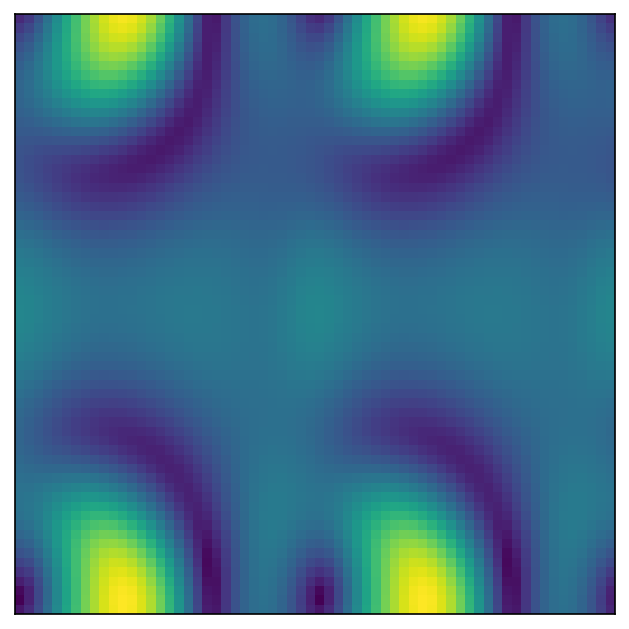

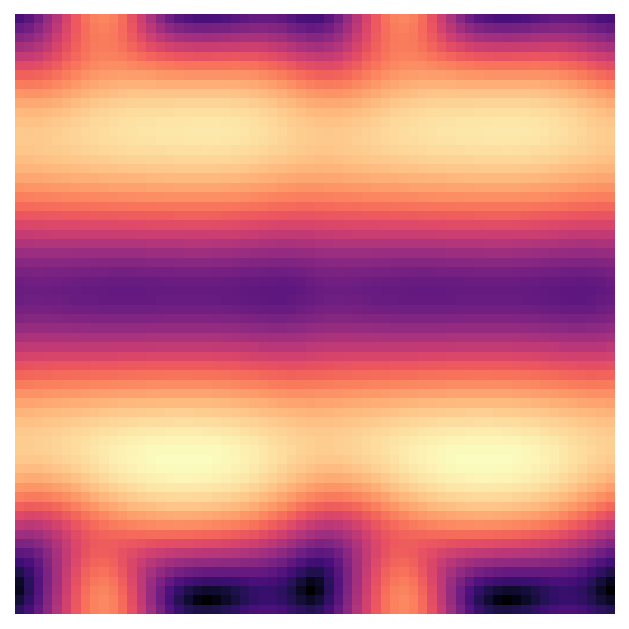

In [7]:
snap = 199

vel_mag = np.sqrt(
    U_clean[:, :, snap, 0] ** 2 + U_clean[:, :, snap, 1] ** 2
)

# ------------------ Figure 1: |u| (clean) ------------------
fig1, ax1 = plt.subplots(figsize=(6, 4), dpi=150)

im0 = ax1.imshow(
    vel_mag,
    origin="lower",
    extent=(0, L, 0, L),
    cmap="viridis",
)

ax1.set_xticks([])
ax1.set_yticks([])
# ax1.set_axis_off()

plt.tight_layout(pad=0)
plt.show()

# ------------------ Figure 2: noise std σ(x,y,t) ------------------
fig2, ax2 = plt.subplots(figsize=(6, 4), dpi=150)

im1 = ax2.imshow(
    std[:,:,snap],
    origin="lower",
    extent=(0, L, 0, L),
    cmap="magma",
)

ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_axis_off()

plt.tight_layout(pad=0)
plt.show()


$$\begin{aligned}
u_t &= -(u u_x + v u_y) - \frac{1}{\rho}\left(p_x - \mu(\,u_{xx} + u_{yy}\,)\right),\\[4pt]
v_t &= -(u v_x + v v_y) - \frac{1}{\rho}\left(p_y - \mu(\,v_{xx} + v_{yy}\,)\right),\\[4pt]
\rho_t &= -\left(\frac{u p_x + v p_y}{RT} + \rho u_x + \rho v_y\right),
\end{aligned}$$

In [8]:
print(np.min(np.abs(u_field)))
print(np.max(np.abs(u_field)))


3.061616997868383e-17
2.8788684493755157


In [9]:
library_functions = [
    lambda x: x,
    lambda x: 1 / (1e-6 + np.abs(x))
]
library_function_names = [
    lambda x: x,
    lambda x: x + "^-1"
]

base_library = ps.CustomLibrary(
    library_functions=library_functions,
    function_names=library_function_names
)
weak_lib_ref = WeakPDELibrary(
    function_library=ps.CustomLibrary(library_functions=library_functions,function_names=library_function_names),
    derivative_order=2,
    spatiotemporal_grid=grid,
    K=1000,
    p=2,
    H_xt=[L / 10, L / 10, T / 10],
    include_bias=False
)



In [10]:
opt_ref = ps.STLSQ(threshold=0.5, alpha=1e-12)
model_ref = ps.SINDy(feature_library=weak_lib_ref, optimizer=opt_ref)

model_ref.fit(U_clean, t=t)

print("\nReference model (clean data):")
model_ref.print()

true_coef = model_ref.optimizer.coef_.copy()  # shape (n_states=3, n_terms)
C_true_flat = true_coef.reshape(-1)
print("\ntrue_coef shape:", true_coef.shape)



Reference model (clean data):
(x0)' = -0.990 x1x0_2 + 1.004 x2^-1x0_22 + -0.996 x0x0_1 + -1.001 x2^-1x2_1 + 1.001 x2^-1x0_11
(x1)' = -0.998 x1x1_2 + -1.000 x2^-1x2_2 + 1.002 x2^-1x1_22 + -0.996 x0x1_1 + 1.000 x2^-1x1_11
(x2)' = -1.000 x2x1_2 + -1.000 x1x2_2 + -1.000 x2x0_1 + -1.000 x0x2_1

true_coef shape: (3, 111)


In [19]:
# --- Weak and weighted libraries for noisy data ------------------------
np.random.seed(0)
weak_lib = WeakPDELibrary(
    function_library=base_library,
    derivative_order=2,
    spatiotemporal_grid=grid,
    is_uniform=True,
    K=1000,
    p=2,
    include_bias=False,
    H_xt=[L / 10, L / 10, T / 40],
)

print("hi")




hi


In [20]:
variance_scaled = variance/np.mean(variance)
np.random.seed(0)
weighted_weak_lib_var = WeightedWeakPDELibrary(
    function_library=base_library,
    derivative_order=2,
    spatiotemporal_grid=grid,
    spatiotemporal_weights=variance_scaled,   # (Nt, N, N)
    is_uniform=True,
    K=1000,
    p=2,
    H_xt=[L / 10, L / 10, T / 40],
)

print("hi")

np.random.seed(0)
weighted_weak_lib_ones = WeightedWeakPDELibrary(
    function_library=base_library,
    derivative_order=2,
    spatiotemporal_grid=grid,
    spatiotemporal_weights=np.ones_like(variance),
    is_uniform=True,
    K=1000,
    p=2,
    H_xt=[L / 10, L / 10, T / 40],
)


hi


In [21]:
opt_std  = ps.STLSQ(threshold=0.5,alpha=1e-8)
opt_std  = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.5,alpha=1e-8),
                                n_models=100, bagging=True)
opt_var  = ps.STLSQ(threshold=0.5,alpha=1e-8)
opt_var  = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.5,alpha=1e-8),
                                n_models=100, bagging=True, library_ensemble=True)
opt_ones = ps.STLSQ(threshold=0.5,alpha=1e-8)
opt_ones  = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.5,alpha=1e-8),
                                n_models=100, bagging=True)

model_std  = ps.SINDy(feature_library=weak_lib,              optimizer=opt_std)
model_var  = ps.SINDy(feature_library=weighted_weak_lib_var, optimizer=opt_var)
model_ones = ps.SINDy(feature_library=weighted_weak_lib_ones,optimizer=opt_ones)

model_std.fit(U_noisy, t=t)
model_var.fit(U_noisy, t=t)
model_ones.fit(U_noisy, t=t)

print("\n===== Weak SINDy (no weighting) =====")
model_std.print()
print("\n===== Weighted Weak SINDy (variance GLS) =====")
model_var.print()
print("\n===== Weighted Weak SINDy (weights = 1 GLS) =====")
model_ones.print()


# --- Stack ensemble coefficients: (E, n_states, n_terms) ---------------
coef_std   = np.stack(opt_std.coef_list,   axis=0)
coef_var   = np.stack(opt_var.coef_list,   axis=0)
coef_ones  = np.stack(opt_ones.coef_list,  axis=0)

print("coef_std shape:  ", coef_std.shape)
print("coef_var shape:  ", coef_var.shape)
print("coef_ones shape: ", coef_ones.shape)



===== Weak SINDy (no weighting) =====
(x0)' = -0.721 x1x0_2 + 0.974 x2^-1x0_22 + -0.959 x0x0_1 + -1.000 x2^-1x2_1 + 0.994 x2^-1x0_11
(x1)' = -4.101 x0_2 + -3.238 x1_11 + 1.960 x2x0_2 + 1.711 x2^-1x0_2 + -0.881 x2^-1x2_2 + 0.940 x2^-1x1_22 + -0.854 x1x0_12 + 1.678 x2x1_11 + 2.473 x2^-1x1_11
(x2)' = -1.001 x2x1_2 + -1.009 x1x2_2 + -0.994 x2x0_1 + -0.980 x0x2_1

===== Weighted Weak SINDy (variance GLS) =====
(x0)' = -0.852 x1x0_2 + 0.992 x2^-1x0_22 + -0.988 x0x0_1 + -0.997 x2^-1x2_1 + 0.997 x2^-1x0_11
(x1)' = -0.982 x1x1_2 + -0.982 x2^-1x2_2 + 0.989 x2^-1x1_22 + -0.957 x0x1_1 + 0.998 x2^-1x1_11
(x2)' = -1.002 x2x1_2 + -1.014 x1x2_2 + -1.001 x2x0_1 + -0.997 x0x2_1

===== Weighted Weak SINDy (weights = 1 GLS) =====
(x0)' = 2.293 x0_2 + -0.705 x1x0_2 + -1.034 x2x0_2 + -1.302 x2^-1x0_2 + 0.976 x2^-1x0_22 + -0.980 x0x0_1 + -1.002 x2^-1x2_1 + 0.995 x2^-1x0_11
(x1)' = -5.108 x0_2 + 1.646 x1_1 + -3.576 x1_11 + -0.679 x1x0_2 + 2.628 x2x0_2 + 2.488 x2^-1x0_2 + -1.018 x1x1_2 + -0.903 x2^-1x2_2 + 0.

In [44]:
def coeff_errors(C_est, C_true, tol_support=1e-6, tol_rel=1e-8):
    """
    Relative L1 error + L0 support mismatch for a single coefficient vector.

    C_est, C_true : 1D arrays of same length.
    """
    C_est = np.asarray(C_est).ravel()
    C_true = np.asarray(C_true).ravel()

    # L0 support mismatch
    supp_true = np.abs(C_true) > tol_support
    supp_est  = np.abs(C_est)  > tol_support
    l0_err = np.count_nonzero(supp_true ^ supp_est)

    # Relative L1 on nonzero true coefficients
    if np.any(supp_true):
        C_true_nz = C_true[supp_true]
        C_est_nz  = C_est[supp_true]
        denom = np.maximum(np.abs(C_true_nz), tol_rel)
        rel_err = np.abs(C_est_nz - C_true_nz) / denom
        l1_rel = np.mean(rel_err)
    else:
        l1_rel = 0.0

    return l1_rel, l0_err


In [45]:

E, n_states, n_terms = coef_var.shape

rel_L1_std,  rel_L1_var,  rel_L1_ones  = [], [], []
L0_std,      L0_var,      L0_ones      = [], [], []

for e in range(E):
    C_std_e  = coef_std[e].reshape(-1)
    C_var_e  = coef_var[e].reshape(-1)
    C_ones_e = coef_ones[e].reshape(-1)

    l1_s, l0_s   = coeff_errors(C_std_e,  C_true_flat)
    l1_v, l0_v   = coeff_errors(C_var_e,  C_true_flat)
    l1_o, l0_o   = coeff_errors(C_ones_e, C_true_flat)

    rel_L1_std.append(l1_s);   L0_std.append(l0_s)
    rel_L1_var.append(l1_v);   L0_var.append(l0_v)
    rel_L1_ones.append(l1_o);  L0_ones.append(l0_o)

rel_L1_std  = np.asarray(rel_L1_std)
rel_L1_var  = np.asarray(rel_L1_var)
rel_L1_ones = np.asarray(rel_L1_ones)

L0_std  = np.asarray(L0_std,  dtype=int)
L0_var  = np.asarray(L0_var,  dtype=int)
L0_ones = np.asarray(L0_ones, dtype=int)

print("\nSingle-trajectory ensemble (noisy data):")
print("  Mean relative L1 (no weighting):      ", np.mean(rel_L1_std))
print("  Mean relative L1 (variance GLS):      ", np.mean(rel_L1_var))
print("  Mean relative L1 (weights=1 GLS):     ", np.mean(rel_L1_ones))
print("  Mean L0 (no weighting):               ", np.mean(L0_std))
print("  Mean L0 (variance GLS):               ", np.mean(L0_var))
print("  Mean L0 (weights=1 GLS):              ", np.mean(L0_ones))



Single-trajectory ensemble (noisy data):
  Mean relative L1 (no weighting):       0.3321754169838643
  Mean relative L1 (variance GLS):       0.0525115256691034
  Mean relative L1 (weights=1 GLS):      0.36763383402120836
  Mean L0 (no weighting):                17.17
  Mean L0 (variance GLS):                1.95
  Mean L0 (weights=1 GLS):               23.76


In [46]:
coeff_errors(opt_std.coef_.reshape(-1),C_true_flat)


(np.float64(0.2881997880970261), 8)

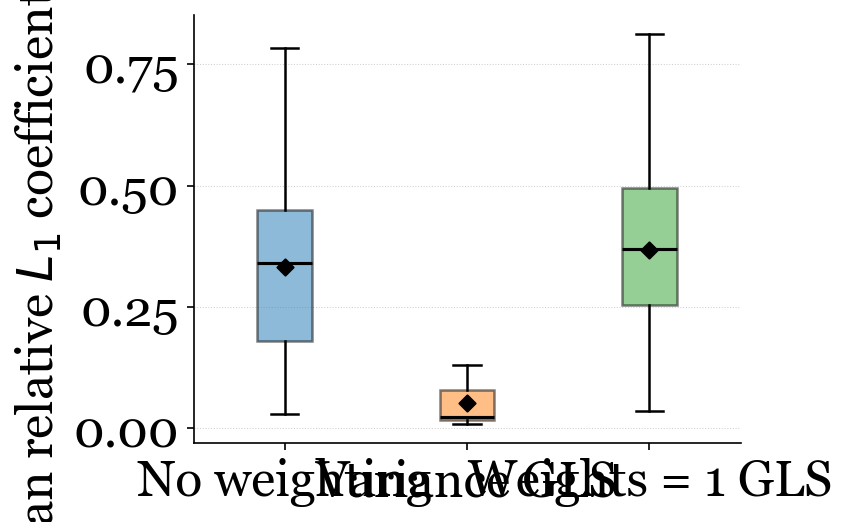

In [47]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

data   = [rel_L1_std, rel_L1_var, rel_L1_ones]
labels = ["No weighting", "Variance GLS", "Weights = 1 GLS"]
means  = [np.mean(d) for d in data]

bp = ax.boxplot(
    data,
    labels=labels,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)

colors = ["tab:blue", "tab:orange", "tab:green"]
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.5)

for x, m in zip([1, 2, 3], means):
    ax.scatter(x, m, marker="D", color="black", s=30, zorder=3)

ax.set_ylabel(r"Mean relative $L_1$ coefficient error")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()


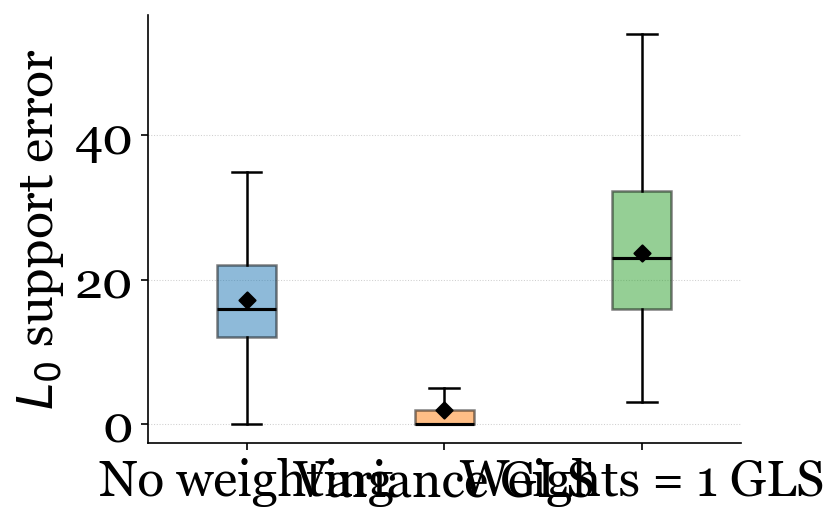

In [48]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

data_L0   = [L0_std, L0_var, L0_ones]
labels_L0 = ["No weighting", "Variance GLS", "Weights = 1 GLS"]
means_L0  = [np.mean(d) for d in data_L0]

bp = ax.boxplot(
    data_L0,
    labels=labels_L0,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)

colors_L0 = ["tab:blue", "tab:orange", "tab:green"]
for patch, c in zip(bp["boxes"], colors_L0):
    patch.set_facecolor(c)
    patch.set_alpha(0.5)

for x, m in zip([1, 2, 3], means_L0):
    ax.scatter(x, m, marker="D", color="black", s=30, zorder=3)

ax.set_ylabel(r"$L_0$ support error")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()


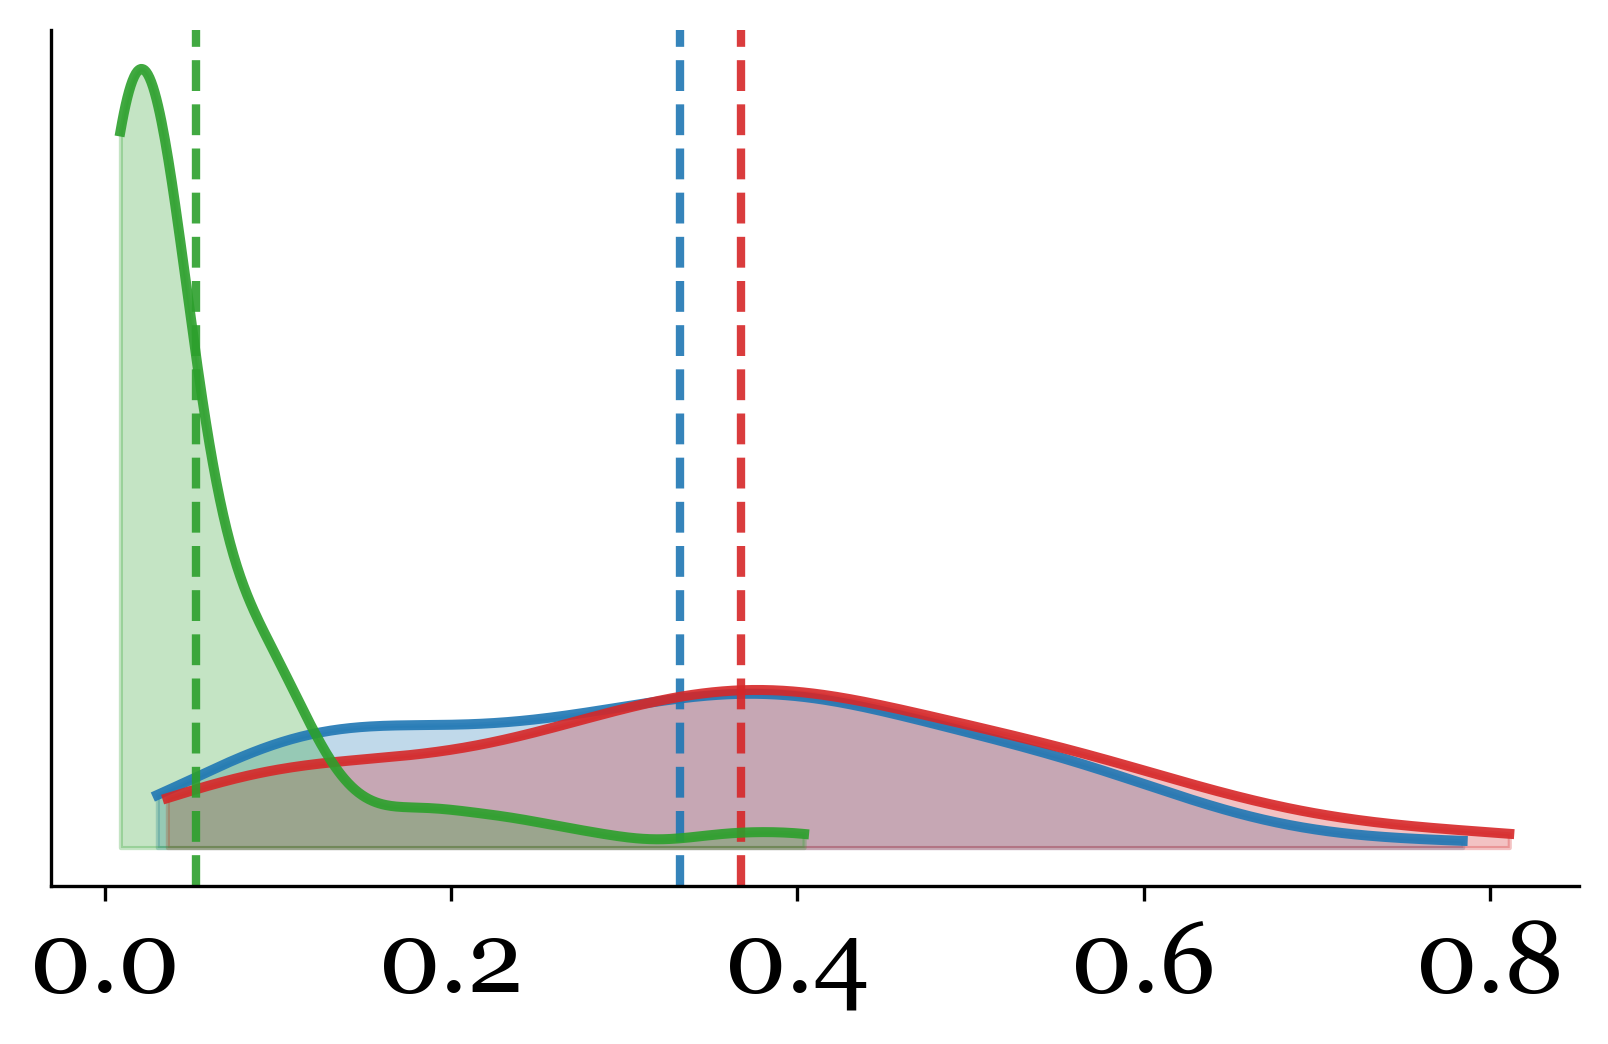

In [49]:
from scipy.stats import gaussian_kde

# --------------------------------------------------------------------
# Publication-quality Density Plot: Accuracy (relative L1)
# --------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 24,
})

rel_L1_all = [
    rel_L1_std,
    rel_L1_ones,
    rel_L1_var
]

colors = ["#1f77b4", "#d62728", "#2ca02c"]  # blue, red, green

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# KDE curves + mean lines
for data, color in zip(rel_L1_all, colors):

    # KDE
    kde = gaussian_kde(data)
    x_eval = np.linspace(min(data), max(data), 400)
    y_eval = kde(x_eval)

    ax.plot(x_eval, y_eval, color=color, lw=2.4, alpha=0.9)
    ax.fill_between(x_eval, y_eval, alpha=0.28, color=color)

    # Mean vertical line
    mean_val = np.mean(data)
    ax.axvline(mean_val, linestyle="--", color=color, lw=2.0, alpha=0.9)

# No x-ticks (legend added externally)
ax.set_yticks([])

# ax.set_ylabel(r"$L_1$ error")

# Aesthetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()


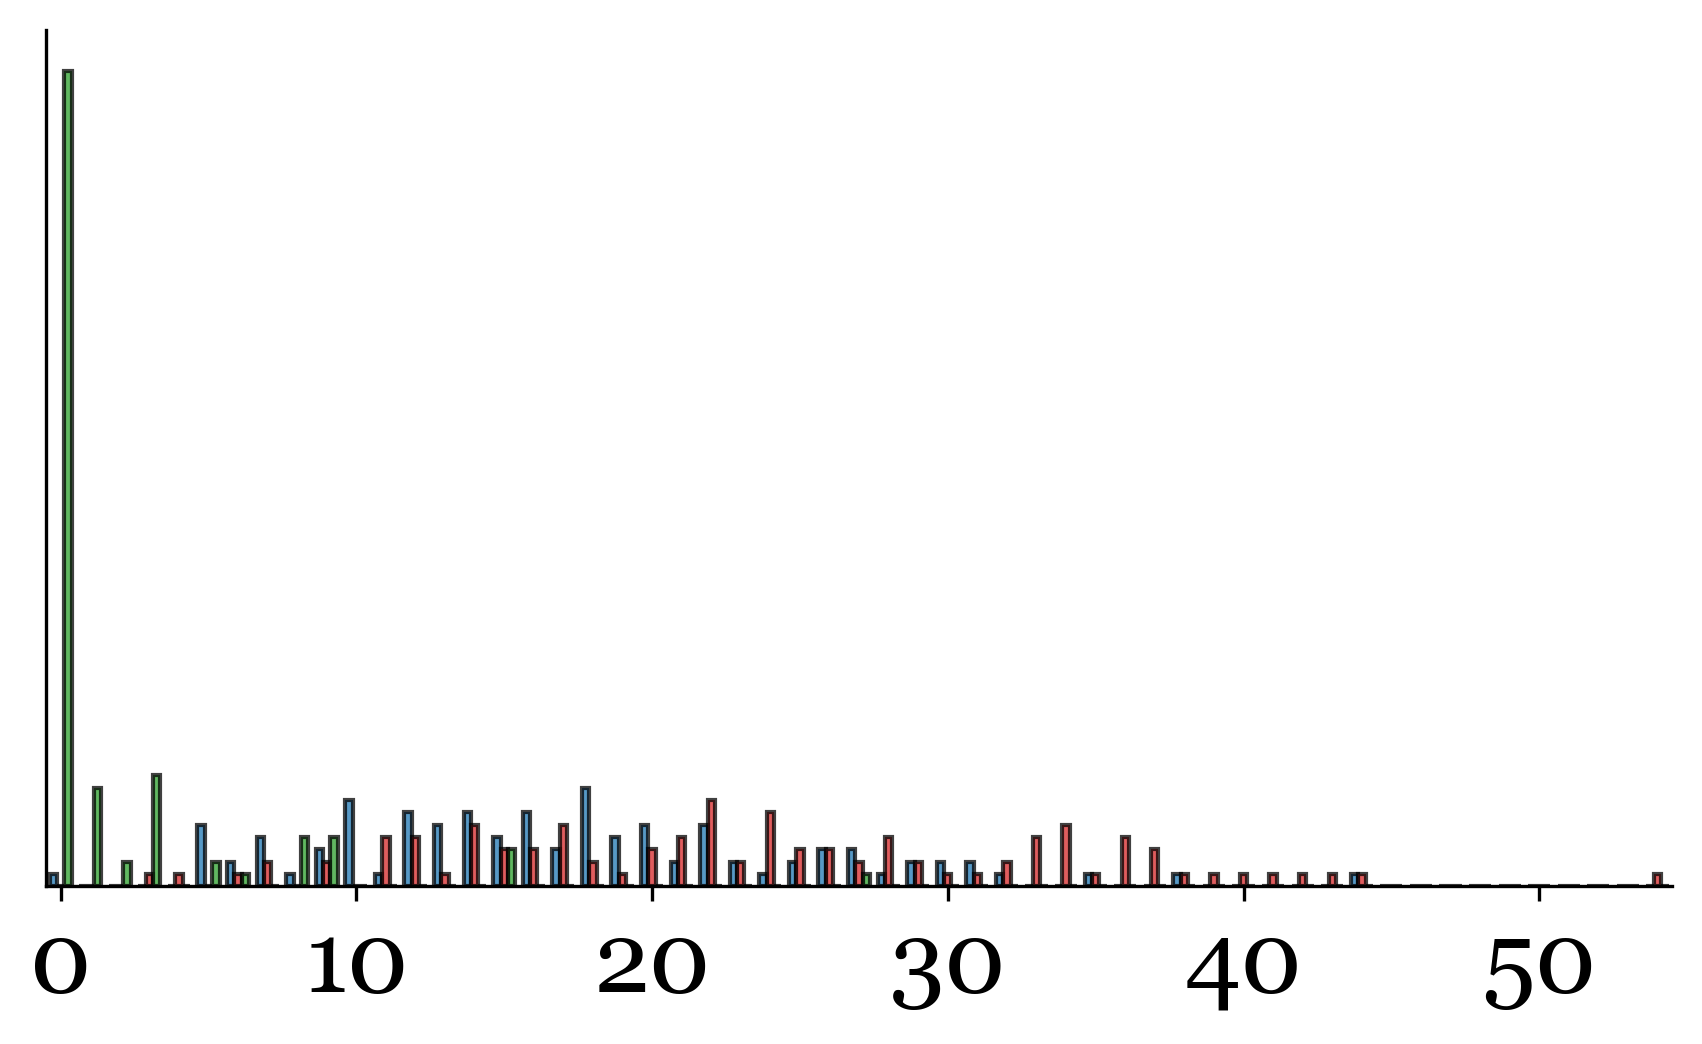

In [53]:
# --------------------------------------------------------------------
# Publication-quality Plot: L0 error distribution (grouped bar plot)
# --------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 24,
})

# Convert arrays
L0_std  = np.asarray(L0_std)
L0_var  = np.asarray(L0_var)
L0_ones = np.asarray(L0_ones)

# Maximum L0 across all methods
k_max = int(max(L0_std.max(), L0_var.max(), L0_ones.max()))
k_vals = np.arange(0, k_max + 1, dtype=int)

# Count occurrences of each L0 error value
counts_std  = np.bincount(L0_std,  minlength=k_max + 1)
counts_var  = np.bincount(L0_var,  minlength=k_max + 1)
counts_ones = np.bincount(L0_ones, minlength=k_max + 1)

# Colors used in earlier figures
colors = ["#1f77b4", "#d62728", "#2ca02c"]  # blue, red, green
width  = 0.25

fig, ax = plt.subplots(figsize=(6.2, 4.0), dpi=300)

# Grouped bars
ax.bar(k_vals - width,
       counts_std,
       width=width,
       color=colors[0],
       alpha=0.75,
       edgecolor="black")

ax.bar(k_vals,
       counts_ones,
       width=width,
       color=colors[1],
       alpha=0.75,
       edgecolor="black")

ax.bar(k_vals + width,
       counts_var,
       width=width,
       color=colors[2],
       alpha=0.75,
       edgecolor="black")

# Axis labels
# ax.set_xlabel(r"$L_0$ support mismatch")
# ax.set_ylabel("Frequency")
ax.set_xticks(k_vals[::10])
ax.set_yticks([])
ax.set_xlim(-0.5, k_max + 0.5)

# No legend (you will add it externally)
# ax.legend(...)

# Aesthetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()
